# DeepScaleR held-out eval curves (AIME + BRUMO) and full eval summary table

Uses the best-step held-out eval runs described in `experiment.md`'s "Best-step
held-out evals (BRUMO / HMMT / AIME 2025)" section: each seed's checkpoint at
its own best in-training AIME `eval/pass_at_1` step, re-evaluated in a single
`open_instruct/grpo.py --eval_only` job on BRUMO 2025, HMMT Feb 2025, HMMT Nov
2025, and AIME 2025 (wandb group `deepscaler_eval_best`; per-benchmark scores
land in `eval/pass_at_1/math_<benchmark>`).

In [1]:
from __future__ import annotations

import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import wandb
from IPython.display import display

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "figures"
CACHE_DIR = NOTEBOOK_DIR / ".cache" / "deepscaler_held_out_evals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

api = wandb.Api(timeout=90)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Run registry — held-out eval-only runs (`deepscaler_eval_best` group)

In [3]:
# Run ids resolved from the wandb group "deepscaler_eval_best" (22 runs total).
# One duplicate: ngu05_n8_k16 seed2 has an early attempt ("bmp44kuk") that landed
# on a packed node and a later full-node relaunch ("51rfa2xt", commit fc3dfa292);
# per experiment.md we keep the relaunch. ngu075_n8_k16 has no seed2 (that
# training seed was excluded upstream after a step-832 failure with no rerun),
# so it's seeds 1/3/4 instead.
RUN_SPECS = [
    # --- baseline N/K sweep ---
    {"setting": "N=16, K=8", "seed": 1, "run_id": "1h44dlnv"},
    {"setting": "N=16, K=8", "seed": 2, "run_id": "gs2py7zz"},
    {"setting": "N=16, K=8", "seed": 3, "run_id": "464b39pb"},
    {"setting": "N=8, K=16", "seed": 1, "run_id": "7c31nrd9"},
    {"setting": "N=8, K=16", "seed": 2, "run_id": "6umb8a5q"},
    {"setting": "N=8, K=16", "seed": 3, "run_id": "5u41b86j"},
    {"setting": "N=4, K=32", "seed": 1, "run_id": "0koxkspr"},
    {"setting": "N=4, K=32", "seed": 2, "run_id": "tqbr42kv"},
    {"setting": "N=4, K=32", "seed": 3, "run_id": "blg2jhnj"},
    {"setting": "N=2, K=64", "seed": 1, "run_id": "5vd884b7"},
    {"setting": "N=2, K=64", "seed": 2, "run_id": "tpfch7n6"},
    {"setting": "N=2, K=64", "seed": 3, "run_id": "v23ad4q6"},
    # --- NGU p sweep (N=8, K=16 only) ---
    {"setting": "NGU p=0.5", "seed": 1, "run_id": "iln3zl9u"},
    {"setting": "NGU p=0.5", "seed": 2, "run_id": "51rfa2xt"},  # full-node relaunch of bmp44kuk
    {"setting": "NGU p=0.5", "seed": 3, "run_id": "ya9bgspb"},
    {"setting": "NGU p=0.75", "seed": 1, "run_id": "65s1s53b"},
    {"setting": "NGU p=0.75", "seed": 3, "run_id": "25m0gd6w"},
    {"setting": "NGU p=0.75", "seed": 4, "run_id": "sd0qh6bu"},
    {"setting": "NGU p=0.875", "seed": 1, "run_id": "rjyxvuxy"},
    {"setting": "NGU p=0.875", "seed": 2, "run_id": "r3wkxdha"},
    {"setting": "NGU p=0.875", "seed": 3, "run_id": "njk40iiq"},
]

BASELINE_SETTING_ORDER = ["N=16, K=8", "N=8, K=16", "N=4, K=32", "N=2, K=64"]
NGU_SETTING_ORDER = ["N=8, K=16", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
ALL_SETTING_ORDER = ["N=16, K=8", "N=8, K=16", "N=4, K=32", "N=2, K=64", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]

K_BY_SETTING = {"N=16, K=8": 8, "N=8, K=16": 16, "N=4, K=32": 32, "N=2, K=64": 64}
P_BY_SETTING = {"N=8, K=16": 0.0, "NGU p=0.5": 0.5, "NGU p=0.75": 0.75, "NGU p=0.875": 0.875}

BENCHMARKS = {
    "AIME 2025": "math_aime_2025",
    "BRUMO 2025": "math_brumo_2025",
    "HMMT Feb 2025": "math_hmmt_feb_2025",
    "HMMT Nov 2025": "math_hmmt_nov_2025",
}

print(f"{len(RUN_SPECS)} held-out eval runs registered across {len(ALL_SETTING_ORDER)} settings")

21 held-out eval runs registered across 7 settings


## Download eval summaries (cached to disk under `notebooks/.cache/deepscaler_held_out_evals/`)

In [4]:
SUMMARY_KEYS = ["eval/pass_at_1"] + [f"eval/pass_at_1/{col}" for col in BENCHMARKS.values()]


def download_eval_summary(run_id: str) -> dict:
    cache_path = CACHE_DIR / f"{run_id}_summary.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as fh:
            return pickle.load(fh)
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    data = {
        "run_id": run_id,
        "run_name": run.name,
        "state": run.state,
        "summary": {k: run.summary.get(k) for k in SUMMARY_KEYS},
    }
    with open(cache_path, "wb") as fh:
        pickle.dump(data, fh)
    return data


rows = []
for spec in RUN_SPECS:
    raw = download_eval_summary(spec["run_id"])
    assert raw["state"] == "finished", f"{spec['run_id']} ({raw['run_name']}) is not finished: {raw['state']}"
    summary = raw["summary"]
    for label, col in BENCHMARKS.items():
        value = summary.get(f"eval/pass_at_1/{col}")
        if value is None:
            continue
        rows.append({
            "setting": spec["setting"], "seed": spec["seed"], "run_id": spec["run_id"],
            "benchmark": label, "pass_at_1": float(value),
        })

long_df = pd.DataFrame(rows)
long_df["setting"] = pd.Categorical(long_df["setting"], categories=ALL_SETTING_ORDER, ordered=True)
long_df["benchmark"] = pd.Categorical(long_df["benchmark"], categories=list(BENCHMARKS), ordered=True)
long_df = long_df.sort_values(["setting", "seed", "benchmark"]).reset_index(drop=True)

print(f"{len(long_df)} (setting, seed, benchmark) rows from {long_df['run_id'].nunique()} runs")
display(long_df.pivot_table(index=["setting", "seed"], columns="benchmark", values="pass_at_1", observed=True))

84 (setting, seed, benchmark) rows from 21 runs


benchmark         AIME 2025  BRUMO 2025  HMMT Feb 2025  HMMT Nov 2025
setting     seed                                                     
N=16, K=8   1      0.156250    0.246875       0.050000       0.033333
            2      0.214583    0.286458       0.100000       0.097917
            3      0.198958    0.260417       0.094792       0.075000
N=8, K=16   1      0.215625    0.296875       0.098958       0.106250
            2      0.209375    0.314583       0.129167       0.093750
            3      0.196875    0.291667       0.112500       0.084375
N=4, K=32   1      0.201042    0.250000       0.095833       0.086458
            2      0.195833    0.284375       0.098958       0.072917
            3      0.215625    0.301042       0.107292       0.071875
N=2, K=64   1      0.193750    0.269792       0.108333       0.078125
            2      0.204167    0.252083       0.088542       0.091667
            3      0.207292    0.292708       0.087500       0.064583
NGU p=0.5   1      0.237500    0.294792       0.096875       0.077083
            2      0.214583    0.287500       0.084375       0.072917
            3      0.207292    0.290625       0.102083       0.095833
NGU p=0.75  1      0.216667    0.291667       0.092708       0.097917
            3      0.209375    0.303125       0.100000       0.073958
            4      0.226042    0.298958       0.106250       0.071875
NGU p=0.875 1      0.209375    0.262500       0.088542       0.090625
            2      0.228125    0.266667       0.088542       0.080208
            3      0.208333    0.303125       0.078125       0.073958

## Plot theme

In [5]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# Distinct from the Blues/Greys setting palettes used elsewhere: here color encodes
# the benchmark (AIME vs. BRUMO), not the training setting.
benchmark_palette = dict(zip(["AIME 2025", "BRUMO 2025"], sns.color_palette("colorblind", 2)))

## Held-out AIME + BRUMO pass@1 curves, at each seed's own best step

Two curves (AIME 2025, BRUMO 2025) plotted against each sweep's natural
continuous axis: `K` (samples per prompt) for the baseline N/K sweep, and
`never_give_up` `p` for the NGU sweep (`N=8, K=16` doubles as the `p=0`
anchor point).

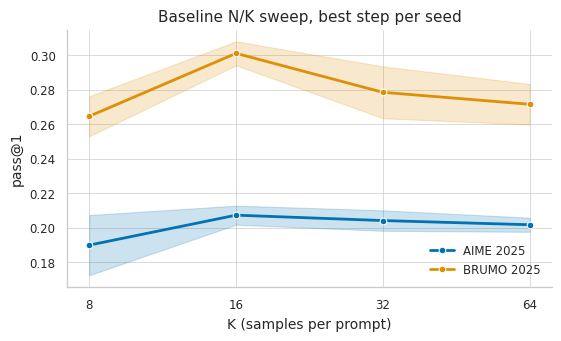

In [6]:
def build_curve_df(setting_order: list[str], x_map: dict[str, float], benchmarks: list[str]) -> pd.DataFrame:
    sub = long_df[long_df["setting"].isin(setting_order) & long_df["benchmark"].isin(benchmarks)].copy()
    sub["x"] = sub["setting"].map(x_map).astype(float)
    return sub


def plot_benchmark_curve(
    df: pd.DataFrame, x_ticks: list[float], x_label: str, palette: dict, out_name: str,
    title: str | None = None, xscale: str | None = None,
):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    sns.lineplot(
        data=df, x="x", y="pass_at_1", hue="benchmark", hue_order=list(palette), palette=palette,
        errorbar="se", estimator="mean", marker="o", ax=ax,
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel("pass@1")
    if xscale == "log2":
        ax.set_xscale("log", base=2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(t) for t in x_ticks])
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_curve_df = build_curve_df(BASELINE_SETTING_ORDER, K_BY_SETTING, ["AIME 2025", "BRUMO 2025"])
plot_benchmark_curve(
    baseline_curve_df, [8, 16, 32, 64], "K (samples per prompt)", benchmark_palette,
    "deepscaler_baseline_aime_brumo_pass_at_1_vs_k.pdf", "Baseline N/K sweep, best step per seed", xscale="log2",
)
plt.show()

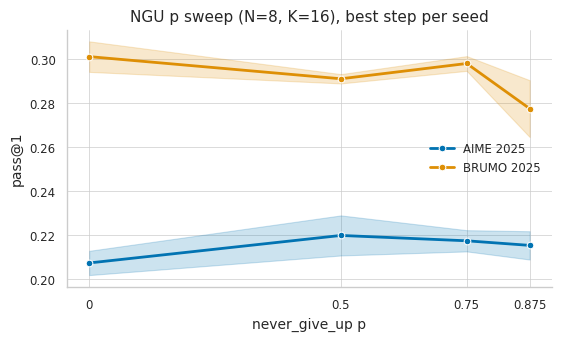

In [7]:
ngu_curve_df = build_curve_df(NGU_SETTING_ORDER, P_BY_SETTING, ["AIME 2025", "BRUMO 2025"])
plot_benchmark_curve(
    ngu_curve_df, [0, 0.5, 0.75, 0.875], "never_give_up p", benchmark_palette,
    "deepscaler_ngu_aime_brumo_pass_at_1_vs_p.pdf", "NGU p sweep (N=8, K=16), best step per seed",
)
plt.show()

## Summary table: all held-out evals by setting, at each seed's own best step

Mean +/- std dev across the seeds of each setting, for every held-out
benchmark (AIME 2025, BRUMO 2025, HMMT Feb 2025, HMMT Nov 2025).

In [8]:
EVAL_TABLE_SECTIONS = [
    ("Baseline N/K sweep", BASELINE_SETTING_ORDER),
    ("NGU p sweep", NGU_SETTING_ORDER),
]

summary_rows = []
for group_name, settings in EVAL_TABLE_SECTIONS:
    for setting in settings:
        row = {"Group": group_name, "Setting": setting}
        for label in BENCHMARKS:
            values = long_df.loc[(long_df["setting"] == setting) & (long_df["benchmark"] == label), "pass_at_1"] * 100
            n = len(values)
            mean = values.mean()
            std = values.std(ddof=1) if n > 1 else 0.0
            row[f"{label} pass@1 (%)"] = f"{mean:.1f} ± {std:.1f} (n={n})" if n > 1 else f"{mean:.1f} (n={n})"
        summary_rows.append(row)

eval_summary_df = pd.DataFrame(summary_rows).set_index(["Group", "Setting"])
eval_summary_df.to_csv(OUTPUT_DIR / "deepscaler_held_out_eval_summary.csv")
display(eval_summary_df)

AIME 2025 pass@1 (%) BRUMO 2025 pass@1 (%) HMMT Feb 2025 pass@1 (%) HMMT Nov 2025 pass@1 (%)
Group              Setting                                                                                                 
Baseline N/K sweep N=16, K=8       19.0 ± 3.0 (n=3)      26.5 ± 2.0 (n=3)          8.2 ± 2.7 (n=3)          6.9 ± 3.3 (n=3)
                   N=8, K=16       20.7 ± 1.0 (n=3)      30.1 ± 1.2 (n=3)         11.4 ± 1.5 (n=3)          9.5 ± 1.1 (n=3)
                   N=4, K=32       20.4 ± 1.0 (n=3)      27.8 ± 2.6 (n=3)         10.1 ± 0.6 (n=3)          7.7 ± 0.8 (n=3)
                   N=2, K=64       20.2 ± 0.7 (n=3)      27.2 ± 2.0 (n=3)          9.5 ± 1.2 (n=3)          7.8 ± 1.4 (n=3)
NGU p sweep        N=8, K=16       20.7 ± 1.0 (n=3)      30.1 ± 1.2 (n=3)         11.4 ± 1.5 (n=3)          9.5 ± 1.1 (n=3)
                   NGU p=0.5       22.0 ± 1.6 (n=3)      29.1 ± 0.4 (n=3)          9.4 ± 0.9 (n=3)          8.2 ± 1.2 (n=3)
                   NGU p=0.75      21.7 ± 0.8 (n=3)      29.8 ± 0.6 (n=3)         10.0 ± 0.7 (n=3)          8.1 ± 1.4 (n=3)
                   NGU p=0.875     21.5 ± 1.1 (n=3)      27.7 ± 2.2 (n=3)          8.5 ± 0.6 (n=3)          8.2 ± 0.8 (n=3)